# Aula 15 - Complemento

- Regressão Linear
- Regressão Logística
- Avaliar modelos de regressão

### Referências

- ▶️ [Linear Regression in 3 Minutes](https://www.youtube.com/watch?v=3dhcmeOTZ_Q)
- ▶️ [Logistic Regression in 3 Minutes](https://www.youtube.com/watch?v=EKm0spFxFG4)
- 📖 [Mastering Logistic Regression with Scikit-Learn: A Complete Guide](https://www.digitalocean.com/community/tutorials/logistic-regression-with-scikit-learn)
- 📖 [Multiple Linear Regression in Python: A Comprehensive Guide](https://www.digitalocean.com/community/tutorials/multiple-linear-regression-python)

# Modelos de regressão

Dada uma quantidade razoável de observações previamente conhecidas, ou seja, pares de entrada e saída

$$y_i = (X_{1i}, \dots,X_{ni}), i=\{0,\dots,m\}$$

- $n$ número de entradas que influenciam $y_i$ (*features*)
- $m$ quantidade de dados utilizados

Um modelo de regressão é utilizado para estimar os coeficientes $\beta_i$ de uma função 

$$
y = f(X_1, \dots, X_n)
$$

que se ajusta aos dados das observações, com **erro mínimo**, e é capaz de prever o valor numérico de uma saída $y$ dadas as características $X_i$

**Observação:** Vale salientar que $y$ pode ser tanto um dado categórico como contínuo

**Observação:** $y=f(X_i)$ pode ser linear (como na regressão linear simples ou múltipla) ou não linear (como na regressão logística). Os modelos apresentados neste notebook requerem que essa função seja linear.

### Exemplo: Valorização de uma casa

Em um conjunto de dados de uma imobiliária, podemos prever o valor de uma casa ($y$) com base nas seguintes variáveis de entrada

- Tamanho da Área construída ($X_1$)
- Tamanho do terreno ($X_2$)
- Número de quartos ($X_3$)
- Número de suites ($X_4$)

### Exemplo: Câncer de mama

No conjunto de dados *Breast cancer* do pacote Scikit Learn, podemos fazer uma regressão para saber se, com base em uma série de características ($X_i$), o tumor de uma mama ser benigno ($y=0$) ou maligno ($y=1$)


In [152]:

from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
X_breast, y_breast = dataset.data, dataset.target

print(f"Quantidade de dados conhecidos (m) = {y_breast.shape[0]}")
print(f"Número de entradas ou features (n) = {X_breast.shape[1]}")
print(f"Características (X1, ..., Xn) = {dataset.feature_names}")
print(f"Label (y) = {dataset.target_names}")

Quantidade de dados conhecidos (m) = 569
Número de entradas ou features (n) = 30
Características (X1, ..., Xn) = ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Label (y) = ['malignant' 'benign']


In [153]:
# Mais informações sobre o dataset breast_cancer
print(dataset.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Nas seções a seguir vamos descobrir que no primeiro exemplo, em que a saída é contínua (o preço de uma casa) pode ser resolvido com uma regressão linear, em que aproximamos o conjunto de dados com um modelo linear. No segundo exemplo, por sua vez, prevemos uma saída categórica (ser o tumor é benígno ou malígno), e para esse caso podemos resolver com uma regressão logística,.

## Regressão Linear

A Regressão Linear Múltipla (MLR) é um método estatístico que modela a relação entre uma variável dependente e duas ou mais variáveis independentes.

Ela é uma extensão da regressão linear simples, que modela a relação entre uma variável dependente e apenas uma variável independente.

Na MLR, a relação é modelada usando a seguinte fórmula

$$
y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n + \varepsilon
$$

- $y$ variável dependente (resposta)
- $X_1, \dots, X_n$ variáveis independentes (preditores)
- $\beta_0$ intercepto (valor médio)
- $\beta_1, \beta_2, ..., \beta_n$ coeficientes que indicam efeito de cada variável $x_i$ sobre $y$
- $\varepsilon$ termo de erro (resíduo)

Antes de implementar a regressão linear múltipla, é essencial garantir que os seguintes pressupostos sejam atendidos:

- A relação entre a variável dependente e as variáveis independentes deve ser linear.
- Os resíduos (erros) devem ser independentes entre si
- A variância dos resíduos deve ser constante ao longo de todos os níveis das variáveis independentes.
- As variáveis independentes não devem ser altamente correlacionadas entre si.
- Os resíduos devem seguir uma distribuição normal.
- Outliers ou pontos de alavancagem alta não devem influenciar desproporcionalmente o modelo

### Exemplo: Dataset California housing

In [154]:
from sklearn.datasets import fetch_california_housing 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

import pandas as pd

# Carrega o dataset California Housing usando a função fetch_california_housing
housing = fetch_california_housing()

# Converte os dados do dataset em um DataFrame do pandas, usando os nomes das features como cabeçalhos das colunas
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Adiciona a variável alvo 'MedHouseValue' ao DataFrame, usando os valores do target do dataset
housing_df['MedHouseValue'] = housing.target

# Seleciona as colunas de features e target
selected_features = ['MedInc', 'AveRooms', 'AveOccup']
X_housing = housing_df[selected_features]
y_housing = housing_df['MedHouseValue']

# Inicializa o objeto StandardScaler
scaler = StandardScaler()

# Ajusta o scaler aos dados e realiza a transformação (normalização)
X_housing_scaled = scaler.fit_transform(X_housing)

X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(X_housing_scaled, y_housing, test_size=0.2, random_state=42)

# Inicialização do regressor linear
model = LinearRegression()
model.fit(X_housing_train, y_housing_train)

# Predição dos valores
y_housing_pred = model.predict(X_housing_test)

### Exemplo: Série temporal com dados de vendas de livros

In [155]:
from pathlib import Path
import numpy as np

dataset_dir = Path('../../Dataset')

book_sales = pd.read_csv(
    dataset_dir / 'book_sales.csv',
    index_col='Date',
    parse_dates=['Date'],
).drop('Paperback', axis=1)

In [156]:
book_sales.head()

,Hardcover
Date,
2000-04-01,139
2000-04-02,128
2000-04-03,172
2000-04-04,139
2000-04-05,191


In [157]:
# Adicionar coluna do step em tempo (time-step feature)
book_sales['Time'] = np.arange(len(book_sales.index))

book_sales.head()

,Hardcover,Time
Date,,
2000-04-01,139,0
2000-04-02,128,1
2000-04-03,172,2
2000-04-04,139,3
2000-04-05,191,4


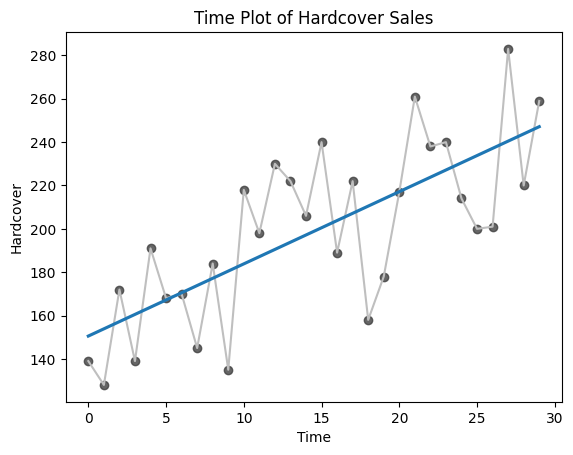

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax.plot('Time', 'Hardcover', data=book_sales, color='0.75')
ax = sns.regplot(x='Time', y='Hardcover', data=book_sales, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title('Time Plot of Hardcover Sales');

In [159]:
from sklearn.linear_model import LinearRegression

X_book_sales = book_sales[['Time']]
y_book_sales = book_sales['Hardcover']

# Treinar o modelo
lrm = LinearRegression()
lrm.fit(X_book_sales, y_book_sales)

# Ajustar os dados de treino usando a regressão linear
y_book_sales_pred = pd.Series(lrm.predict(X_book_sales), index=X_book_sales.index)
y_book_sales_pred

Date
2000-04-01    150.539785
2000-04-02    153.870374
2000-04-03    157.200964
2000-04-04    160.531554
2000-04-05    163.862143
2000-04-06    167.192733
2000-04-07    170.523322
2000-04-08    173.853912
2000-04-09    177.184501
2000-04-10    180.515091
2000-04-11    183.845680
2000-04-12    187.176270
2000-04-13    190.506859
2000-04-14    193.837449
2000-04-15    197.168039
2000-04-16    200.498628
2000-04-17    203.829218
2000-04-18    207.159807
2000-04-19    210.490397
2000-04-20    213.820986
2000-04-21    217.151576
2000-04-22    220.482165
2000-04-23    223.812755
2000-04-24    227.143344
2000-04-25    230.473934
2000-04-26    233.804524
2000-04-27    237.135113
2000-04-28    240.465703
2000-04-29    243.796292
2000-04-30    247.126882
dtype: float64

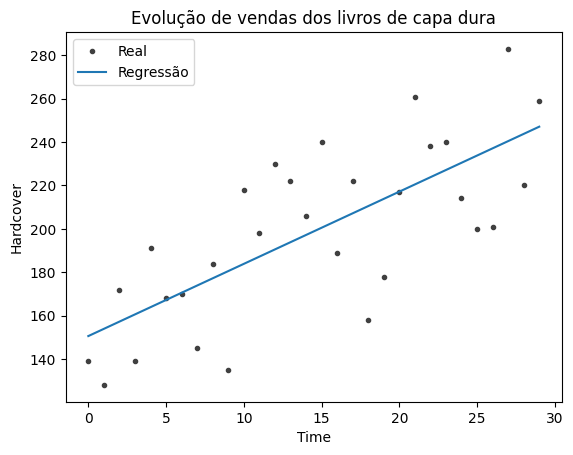

In [176]:
# Visualizar ajuste
fig, ax = plt.subplots()
ax.plot(X_book_sales['Time'], y_book_sales, '.', color='0.25')
ax.plot(X_book_sales['Time'], y_book_sales_pred)
# ax.set_aspect('equal')
ax.set_ylabel('Hardcover')
ax.set_xlabel('Time')
ax.set_title('Evolução de vendas dos livros de capa dura');
ax.legend(['Real', 'Regressão'])

## Regressão Logística

A regressão logística começa com uma combinação linear das variáveis independentes ($X_i$) com a variável categórica $z$ que se deseja prever

$$
z=\beta_0 + \beta_1X_1 + \dots + \beta_nX_n
$$

Para obter a probabilidade da classe positiva, aplicamos a função logística — também conhecida como *sigmoide* — em $z$

$$
\sigma(z) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \dots + \beta_nX_n)}}, 0 < \sigma(z) < 1
$$

Observe que achar os coeficientes $\beta_i$ dessa equação nos permite determinar $p=\sigma(z)$ (a probabilidade de $z$ assumir uma categoria positiva, e.g, tem renda alta, é de classe baixa, contraiu COVID, etc.), dadas as *features* $X_i$

A relação entre $p$ e as *features* é não-linear, mas podemos linearizá-la relacionado as chances de $z$ ($\text{odds}$) com $\sigma(z)$ 

As $\text{odds}$ de $z$ nada mais é do que a razão entre a probabilidade de $z$ ocorrer, dividido pela probabilidade de $z$ não ocorrer

$$
\text{odds} = \frac{p}{1-p} 
$$

Como $p=\sigma(z)$, pode-se provar que a equação linearizada é

$$
\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1X_1 + \dots + \beta_nX_n
$$



In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dividir o conjunto de treino e de teste
X_breast_train, X_breast_test, y_breast_train, y_breast_test = train_test_split(
    X_breast, y_breast, test_size=0.2, random_state=40
)

# Inicializar o modelo de Regressão Logística
model = LogisticRegression(
    penalty='l2',
    C=2.0,
    solver='liblinear',
    max_iter=1000
)

# Treinar o modelo
model.fit(X_breast_train, y_breast_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [162]:
# Predições
y_breast_pred = model.predict(X_breast_test)
y_breast_pred

array([1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1])

*Por que `y_pred` possui 0s e 1s, sendo que o retorno da função sigmoide é contínuo?*

Por mais que o valor previsto na equação da regressão logística seja contínuo — já que a função sigmoide retorna um valor entre 0 e 1, a implementação do Scikit-learn utiliza um valor de limiar (threshold) (por padrão, 0.5) para discretizar essa probabilidade em uma classe binária:
- Se $p\geq0.5$ a classe prevista é 1
- Caso contrário, a classe prevista é 0

# Avaliar modelos de regressão

## Regressão linear

A regressão linear utiliza o erro quadrático médio (MSE – Mean Squared Error) como métrica de avaliação e função de otimização.
O objetivo do modelo é encontrar os coeficientes (pesos) que minimizam a média dos quadrados das diferenças entre os valores reais e os valores previstos.

Essa função de custo recompensa previsões próximas dos valores reais e penaliza mais fortemente os erros grandes, já que os erros são elevados ao quadrado.

O MSE é definido como

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- $n$ número de amostras
- $y_i$ valor real
- $\hat{y_i}$ valor previsto

In [163]:
# Métricas MSE e R²
print("Mean Squared Error (MSE):", mean_squared_error(y_housing_test, y_housing_pred))
print("R-squared:", r2_score(y_housing_test, y_housing_pred))

# Adiciona uma constante (intercepto) ao conjunto de variáveis independentes de treino
X_housing_train_sm = sm.add_constant(X_housing_train)

# Ajusta o modelo de Regressão Linear usando OLS (Mínimos Quadrados Ordinários)
model_sm = sm.OLS(y_housing_train, X_housing_train_sm).fit()

# Exibe o resumo do modelo, com estatísticas e coeficientes
print(model_sm.summary())

Mean Squared Error (MSE): 0.7006855912225249
R-squared: 0.4652924370503557
                            OLS Regression Results                            
Dep. Variable:          MedHouseValue   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     5173.
Date:                Sun, 13 Jul 2025   Prob (F-statistic):               0.00
Time:                        08:36:01   Log-Likelihood:                -20354.
No. Observations:               16512   AIC:                         4.072e+04
Df Residuals:                   16508   BIC:                         4.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

## Regressão Logística

Ao contrário da regressão linear, que foca em minimizar o erro quadrático médio, a regressão logística possui seu próprio método de treinamento. Ela busca minimizar uma função de custo (log loss ou entropia cruzada binária). Essa função avalia o quão precisamente as probabilidades previstas pelo modelo correspondem aos rótulos das classes. Ela recompensa previsões corretas com alta confiança e penaliza as incorretas. 

A log loss é definida como

$$
\text{LogLoss} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$

- $n$ número de amostras
- $y_i$ rótulo real da amostra $i$ (0 ou 1)
- $\hat{y_i}$ probabilidade prevista da classe positiva para a amostra
- $\log$ logaritmo natural (base $e$)

In [164]:
from sklearn.metrics import classification_report

print(classification_report(y_breast_test, y_breast_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        39
           1       0.99      0.97      0.98        75

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

